# **XGBoost** *(Extreme Gradient Boosting)*



El modelo de XGBoost es una biblioteca de machine learning distribuida de código abierto que utiliza árboles de decisión impulsados por gradientes, un algoritmo de aprendizaje boosting que utiliza el descenso de gradiente. Es conocido por su **velocidad, eficiencia y capacidad de escalar** bien con grandes conjuntos de datos. Matemáticamente, la predicción se expresa como:

$$
\mathcal{L}=\sum_i l(y_i,\hat{y}_i)+\sum_k\Omega(f_k)
$$

donde

$$
\Omega(f)=\gamma T+\frac{1}{2}\lambda\sum_{j=1}^{T}w_j^2
$$

La función de pérdida evalúa el error de predicción, mientras que el término de regularización penaliza la complejidad del modelo, favoreciendo árboles más simples y reduciendo el sobreajuste.


---


El modelo fue entrenado con variables morfológicas como la longitud y profundidad del
pico, la longitud de la aleta y la masa corporal, complementadas con la isla de origen y
el sexo del individuo. La estrategia de partición adoptada fue un esquema estratificado
de **80% entrenamiento y 20% prueba**, garantizando la representación
proporcional de las tres especies en cada conjunto.

El desempeño del modelo se evaluó mediante métricas estándar de clasificación: accuracy,
precision, recall y F1-score, tanto por clase como de forma agregada, complementadas con
el análisis de la matriz de confusión y la importancia de variables, con el fin de
obtener una visión integral del comportamiento del clasificador.

In [ ]:
# ──────────────────────────────────────────────
# MODELO XGBOOST — CLASIFICACIÓN DE PINGÜINOS
# ──────────────────────────────────────────────

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

# ── Carga de la base limpia ──────────────────────
pinwinos = pd.read_csv('PinwinosPalmerLimpia.csv')
pinwinos.head()

Mounted at /content/drive


Se utiliza el dataset Palmer Penguins, el cual contiene información de 344 pingüinos con variables como longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, isla de origen y sexo.

Estas variables serán utilizadas como predictores para la clasificación.

In [ ]:
# ── EXPLORACIÓN DE DATOS (EDA) ──────────────────
# Vista general
pinwinos.info()
pinwinos.describe()
pinwinos.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Especie              344 non-null    object 
 1   Isla                 344 non-null    object 
 2   Sexo                 344 non-null    object 
 3   Anio                 344 non-null    int64  
 4   Longitud_Pico_cm     344 non-null    float64
 5   Profundidad_Pico_cm  344 non-null    float64
 6   Longitud_Aleta_cm    344 non-null    float64
 7   Masa_Corporal_kg     344 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


,0
Especie,0
Isla,0
Sexo,0
Anio,0
Longitud_Pico_cm,0
Profundidad_Pico_cm,0
Longitud_Aleta_cm,0
Masa_Corporal_kg,0


In [ ]:
# Codificación de variables categóricas
isla   = LabelEncoder()
sexo   = LabelEncoder()
especie = LabelEncoder()

pinwinos["Isla_enc"] = isla.fit_transform(pinwinos["Isla"])
pinwinos["Sexo_enc"] = sexo.fit_transform(pinwinos["Sexo"])

features = ["Longitud_Pico_cm", "Profundidad_Pico_cm",
            "Longitud_Aleta_cm", "Masa_Corporal_kg",
            "Isla_enc", "Sexo_enc"]

X = pinwinos[features]
y = especie.fit_transform(pinwinos["Especie"])  # Adelie=0, Chinstrap=1, Gentoo=2

# Separación de conjuntos: entrenamiento (80%) del resto (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Entrenamiento : {len(X_train)} obs. ({len(X_train)/len(X)*100:.1f}%)")
print(f"Prueba        : {len(X_test)} obs.  ({len(X_test)/len(X)*100:.1f}%)")

Entrenamiento : 275 obs. (79.9%)
Prueba        : 69 obs.  (20.1%)


### **Configuración del modelo**

El modelo XGBoost se configuró para un problema de clasificación multiclase con tres categorías, utilizando 200 árboles de decisión (`n_estimators = 200`) y una profundidad máxima de 4 niveles (`max_depth = 4`) para equilibrar la capacidad predictiva y la complejidad del modelo. Se estableció una tasa de aprendizaje de 0.1 (`learning_rate = 0.1`), permitiendo que el aprendizaje fuera gradual.

Además, se empleó un muestreo del 80 % de las observaciones (`subsample = 0.8`) y del 80 % de las variables (`colsample_bytree = 0.8`) en cada árbol, con el propósito de incrementar la capacidad de generalización del modelo.

Como métrica de evaluación durante el entrenamiento se utilizó la pérdida logarítmica multiclase (`mlogloss`), mientras que la semilla aleatoria (`random_state = 999999`) garantiza la reproducibilidad de los resultados.

In [ ]:
modelo = xgb.XGBClassifier(
    objective         = "multi:softmax",
    num_class         = 3,
    n_estimators      = 200,
    max_depth         = 4,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    eval_metric       = "mlogloss",
    random_state      = 999999,
    use_label_encoder = False,
)
modelo.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False,
)

print("Modelo entrenado")

Modelo entrenado


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:34:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### **Evaluación del modelo**

Se evalúa el desempeño del modelo en los conjuntos de entrenamiento y prueba mediante las métricas **accuracy**, **precision**, **recall** y **F1-score** por clase. La comparación entre ambos conjuntos permite verificar la capacidad de generalización del modelo e identificar posibles indicios de sobreajuste.

In [ ]:
for nombre, X_ev, y_ev in [
    ("Entrenamiento", X_train, y_train),
    ("Prueba",    X_test,   y_test)
]:
    preds = modelo.predict(X_ev)
    acc   = accuracy_score(y_ev, preds)
    print(f"\n{'─'*45}")
    print(f"  {nombre}  —  Accuracy: {acc:.4f}")
    print(f"{'─'*45}")
    print(classification_report(
        y_ev, preds,
        target_names = especie.classes_,
    ))



─────────────────────────────────────────────
  Entrenamiento  —  Accuracy: 1.0000
─────────────────────────────────────────────
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00       122
   Chinstrap       1.00      1.00      1.00        54
      Gentoo       1.00      1.00      1.00        99

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275


─────────────────────────────────────────────
  Prueba  —  Accuracy: 1.0000
─────────────────────────────────────────────
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1

**Interpretación de resultados**

Los resultados muestran que el modelo alcanzó un **alto desempeño**, sin errores de clasificación tanto en entrenamiento como en prueba. ***(Accuracy = 1)***.

 Esto sugiere que las variables utilizadas (como las medidas anatómicas del pico y la aleta, junto con la información geográfica) poseen una alta capacidad discriminativa, permitiendo diferenciar claramente las tres especies de pingüinos.

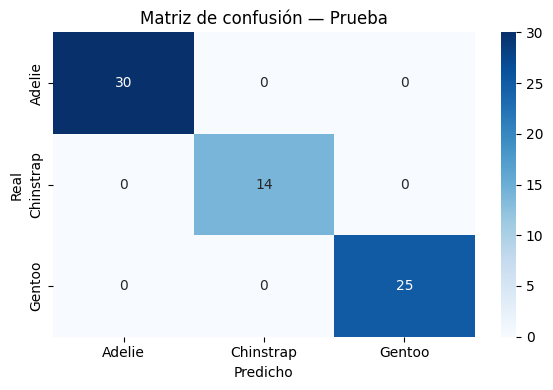

In [9]:
# Matriz de confusión — conjunto de prueba
cm = confusion_matrix(y_test, modelo.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels = especie.classes_,
    yticklabels = especie.classes_,
)
plt.title("Matriz de confusión — Prueba")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

## Interpretación de la Matriz de Confusión — Conjunto de Prueba

La diagonal principal representa los aciertos del modelo:
- **Adelie** → 30 de 30 clasificados correctamente
- **Chinstrap** → 14 de 14 clasificados correctamente
- **Gentoo** → 25 de 25 clasificados correctamente

| | Total en prueba | Aciertos | Errores | Accuracy |
|---|---|---|---|---|
| Resultado | 30 | 14 | 25 | 100% |

## **Importancia de Variables**

---
A continuación, se analiza la importancia de las variables utilizadas en el modelo, con el fin de evaluar su contribución a la capacidad predictiva del clasificador.

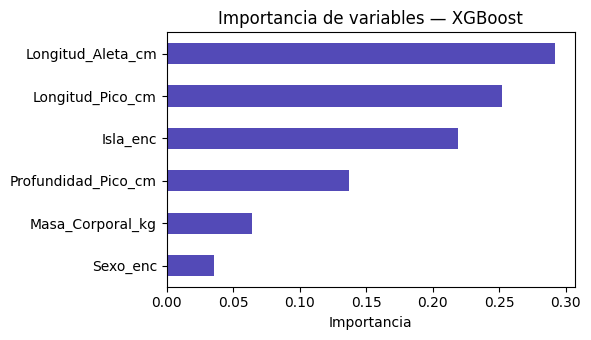

Longitud_Aleta_cm      0.291958
Longitud_Pico_cm       0.252288
Isla_enc               0.218663
Profundidad_Pico_cm    0.136944
Masa_Corporal_kg       0.064279
Sexo_enc               0.035868
dtype: float32


In [ ]:
importancias = pd.Series(
    modelo.feature_importances_,
    index = features
).sort_values(ascending=True)

plt.figure(figsize=(6, 3.5))
importancias.plot(kind="barh", color="#534AB7")
plt.title("Importancia de variables — XGBoost")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()
print(importancias.sort_values(ascending=False))

XGBoost asigna un puntaje a cada variable según qué tanto contribuyó
a reducir el error en los árboles de decisión. Entre más alto el valor,
más útil fue esa variable para clasificar la especie correcta.

### Ranking de variables

| Variable | Importancia | Interpretación |
|---|---|---|
| Longitud_Aleta_cm | 0.291958 | La más importante. Las aletas de Gentoo son notablemente más largas que las de Adelie y Chinstrap |
| Longitud_Pico_cm | 0.252288 | Segunda más importante. Chinstrap tiene el pico más largo de las tres especies |
| Isla_enc | 0.218663 | La isla de origen es casi igual de informativa que las medidas físicas, ya que cada especie habita islas distintas |
| Profundidad_Pico_cm | 0.136944 | Complementa la longitud del pico para separar Adelie (pico más profundo) de las otras dos |
| Masa_Corporal_kg | 0.064279 | Gentoo es considerablemente más pesada, pero esta información ya la captura la longitud de aleta |
| Sexo_enc | 0.035868 | La menos importante. El sexo no discrimina entre especies, solo entre individuos de la misma especie |



---


## ***Conclusión***

El modelo XGBoost obtuvo un desempeño sobresaliente, alcanzando un accuracy de **1.00**, lo que indica una *clasificación perfecta* sobre el conjunto de prueba. El análisis de importancia de variables mostró que las características anatómicas del pico y la aleta concentran aproximadamente el **67 %** de la capacidad predictiva, mientras que la isla de origen aporta un 21 %, confirmando que la información morfológica y geográfica es determinante para distinguir las especies.

En contraste, la variable sexo presentó una contribución mínima, por lo que podría eliminarse sin afectar significativamente el rendimiento del modelo.

A pesar del excelente desempeño obtenido, es importante considerar que el reducido tamaño de la base de datos puede favorecer el sobreajuste del modelo. Esto significa que, aunque XGBoost clasifica correctamente los datos disponibles, su rendimiento podría no ser el mismo al aplicarse sobre nuevas observaciones. Por ello, sería recomendable validar el modelo con una muestra más grande y representativa para confirmar su capacidad de generalización.